# Random Forest  Model

The goal is to train a random forest classifier on the training and validation data, test data will be used to evaluate the final chosen model.

## Import Libraries

In [26]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import RandomizedSearchCV

# This just keeps the notebook output cleaner.
import warnings
warnings.filterwarnings("ignore")

## Load Data and Explore Class Balance

In [2]:
# define data paths
data_dir = Path("processed_data")
train_path = data_dir / "train_final.csv"
val_path = data_dir / "val_final.csv"

# load data
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)

# remove the target and any ID columns from the model inputs.
drop_cols = ["target", "exam_id", "patient_id"]
feature_cols = [
    col for col in train.columns
    if col not in drop_cols
]
# split train and validation data into appropriate X,Y 
X_train = train[feature_cols]
y_train = train["target"]

X_val = validation[feature_cols]
y_val = validation["target"]

In [13]:
# explore data shape
print("--- Shape of Data ---")
print(f"X train: {X_train.shape}")
print(f"y train: {y_train.shape}")
print(f"X validation: {X_val.shape}")
print(f"y validation: {y_val.shape}")
# explore class balance
print("\n--- Class Balance ---")
print("Training Data Counts By Target Value:")
print(train["target"].value_counts().sort_index())
print("Validation Data Counts By Target Value:")
print(validation["target"].value_counts().sort_index())
print("\n--- Positivity Rate ---")
print("Training positive:", round(train["target"].mean(), 3))
print("Validation positive:", round(validation["target"].mean(), 3))

--- Shape of Data ---
X train: (7746, 18)
y train: (7746,)
X validation: (2584, 18)
y validation: (2584,)

--- Class Balance ---
Training Data Counts By Target Value:
target
0    3885
1    3861
Name: count, dtype: int64
Validation Data Counts By Target Value:
target
0    1291
1    1293
Name: count, dtype: int64

--- Positivity Rate ---
Training positive: 0.498
Validation positive: 0.5


Since the data is mostly balanced along classes, accuracy is a useful measure but for the sake of consistency across all teammates work precision, recall, F1, ROC-AUC, and the confusion matrix are also used. 

## Import Baseline

The baseline model created by Rohan is copied over in this notebook for easier comparision of model performance.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_prob = baseline.predict_proba(X_val)[:, 1]

baseline_results = {
    "model": "Baseline",
    "Hyperparameter": np.nan,
    "accuracy": accuracy_score(y_val, baseline_pred),
    "precision": precision_score(y_val, baseline_pred, zero_division=0),
    "recall": recall_score(y_val, baseline_pred, zero_division=0),
    "f1": f1_score(y_val, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, baseline_prob)
}

## Random Forest Classifier

To optimize the Random Forest classifier beyond basic default settings, I implemented Randomized Search Cross-Validation (RandomizedSearchCV) to systematically evaluate multiple parameters simultaneously. Randomized search was chosen as it is more computationally optimal for running the large number of combinations by randomly choosing combinations as opposed to gridsearch which would search all possible combinations.

In [17]:
# Define the grid of parameters to search
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Initialize a base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_grid, 
    n_iter=50,             # Tests 50 random combinations
    scoring='roc_auc',     # Optimizes for ROC-AUC
    cv=5,                  # 5-fold cross-validation
    random_state=42,
    n_jobs=-1
)

# Fit the random search model on the training data
print("Running Randomized Search...")
random_search.fit(X_train, y_train)

# The search automatically saves the best model
best_model = random_search.best_estimator_

print("Best Parameters Found:")
print(random_search.best_params_)

# Generate predictions for the validation set using the new best model
best_pred = best_model.predict(X_val)
best_prob = best_model.predict_proba(X_val)[:, 1]

# Calculate and print validation metrics to compare with your old output
print("\n--- Validation Set Performance ---")
print(f"Accuracy:  {accuracy_score(y_val, best_pred):.6f}")
print(f"Precision: {precision_score(y_val, best_pred, zero_division=0):.6f}")
print(f"Recall:    {recall_score(y_val, best_pred, zero_division=0):.6f}")
print(f"F1 Score:  {f1_score(y_val, best_pred, zero_division=0):.6f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, best_prob):.6f}")

Running Randomized Search...


Best Parameters Found:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 0.3, 'max_depth': 15}

--- Validation Set Performance ---
Accuracy:  0.673762
Precision: 0.661638
Recall:    0.712297
F1 Score:  0.686034
ROC-AUC:   0.751520


## Comparing Baseline vs Tuned Random Forest Classifier

In [ ]:
# extract and format random forest parameters into a readable short string
bp = random_search.best_params_
param_summary = f"depth={bp['max_depth']}, n_est={bp['n_estimators']}, leaf={bp['min_samples_leaf']}, split={bp['min_samples_split']}, feat={bp['max_features']}"

# compile results
rf_results = {
    "model": "Tuned Random Forest",
    "Hyperparameter": param_summary,
    "accuracy": accuracy_score(y_val, best_pred),
    "precision": precision_score(y_val, best_pred, zero_division=0),
    "recall": recall_score(y_val, best_pred, zero_division=0),
    "f1": f1_score(y_val, best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, best_prob)
}

# display performance metrics of baseline and rf as single data frame
results_df = pd.DataFrame([baseline_results, rf_results]).sort_values("roc_auc", ascending=False)
results_df

,model,Hyperparameter,accuracy,precision,recall,f1,roc_auc
1,Tuned Random Forest,"depth=15, n_est=500, leaf=8, split=5, feat=0.3",0.673762,0.661638,0.712297,0.686034,0.75152
0,Baseline,NaN,0.499613,0.000000,0.000000,0.000000,0.50000


Comments: The tuned RF model is a significant improvement over the baseline frequent class predictor with ROC score improving from 0.5 to 0.7515 and accuracy from 49.96% to 67.376%. The tuned RF model also achieves strong recall of 71.23% indicating that it successfully captures majority of the positive cases and maintains a balanced F1 score off 0.686. 

## Confusion Matrix and ROC curve

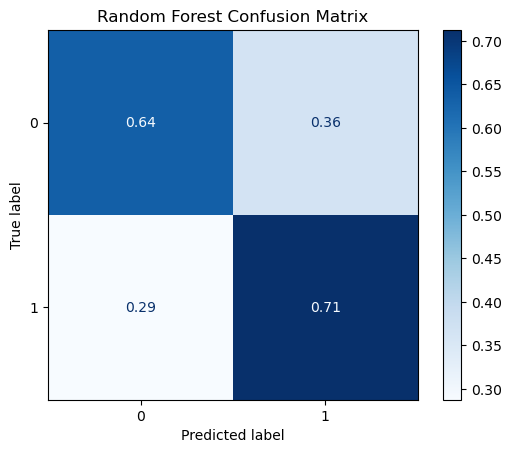

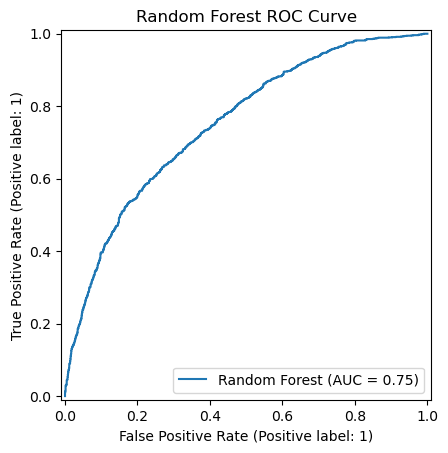

In [ ]:
# plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, 
    best_pred, 
    cmap="Blues", 
    normalize="true"
)
plt.title("Random Forest Confusion Matrix")
plt.show()

# plot ROC Curve
RocCurveDisplay.from_predictions(
    y_val, 
    best_prob, 
    name="Random Forest"
)
plt.title("Random Forest ROC Curve")
plt.show()

Comments: 

The normalized confusion matrix shows that the tuned model achieves a strong positive class identification of about 71% of true positive cases being correctly identified. for the negative class the model correctly predicts 64% of true negatives with a 36% false positive rate and 29% false negative rate. complementing these results are AC curve demonstrates consistent diagnostic capability across the thresholds pulling significantly away from the simplistic diagonal baseline to achieve an AUC off 0.75.

While the overall performance is decent the model struggles with high false positive and false negative rates which affects the overall accuracy and brings it down to 67.4%. this could likely stem from overlapping feature distributions between classes and key predictors that are missing from our data that could help better separate ambiguous cases. Better performance might be observed by engineering features that accommodate for interactions between our heart rate metrics or experimenting with gradient boosting algorithms such as XG boost.

## Export Model Results

To maintain consistency across different notebooks, the model results are extracted into csv files below to include parameter sets tested and their associated performance, as well as feature importances.

In [27]:
# set output folder
output_dir = "model_results"

In [28]:
# convert the search results into a DataFrame
cv_results = pd.DataFrame(random_search.cv_results_)

# identify all hyperparameter columns
param_cols = [col for col in cv_results.columns if col.startswith("param_")]

# extract parameter columns and mean cross-validation score
table_df = cv_results[["rank_test_score"] + param_cols + ["mean_test_score", "std_test_score"]].copy()

# clean up column headers
table_df.columns = [col.replace("param_", "") for col in table_df.columns]
table_df = table_df.rename(columns={
    "mean_test_score": "cv_roc_auc",
    "std_test_score": "std_roc_auc",
    "rank_test_score": "rank"
})

# insert model label at the front
table_df.insert(0, "model", "Random Forest")

# sort by best-performing combination first
table_df = table_df.sort_values(by="rank").reset_index(drop=True)

# save to CSV and display full table
table_df.to_csv(os.path.join(output_dir, "rf_all_parameter_combinations.csv"), index=False)
table_df

,model,rank,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,cv_roc_auc,std_roc_auc
0,Random Forest,1,500,5,8,0.3,15,0.758860,0.012302
1,Random Forest,2,500,10,2,log2,None,0.758106,0.008999
2,Random Forest,3,500,10,2,0.3,20,0.758021,0.009895
3,Random Forest,4,300,5,8,log2,15,0.758000,0.011292
4,Random Forest,5,500,10,2,0.3,15,0.757581,0.011070
5,Random Forest,6,300,5,8,log2,None,0.757549,0.011401
6,Random Forest,6,300,10,8,log2,None,0.757549,0.011401
7,Random Forest,8,500,5,4,0.5,15,0.757122,0.010651
8,Random Forest,9,100,15,8,sqrt,15,0.756908,0.010659
9,Random Forest,10,500,15,2,0.3,15,0.756882,0.010937


In [29]:
# extract importances from the tuned Random Forest model
importances = best_model.feature_importances_

# create a DataFrame matching the feature names
feature_imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
})

# sort by importance in descending order
feature_imp_df = feature_imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

# save to csv and display top features
feature_imp_df.to_csv(os.path.join(output_dir,"rf_feature_importances.csv"), index=False)
feature_imp_df

,feature,importance
0,age,0.180922
1,ST_segment_mean,0.087634
2,HRV_SDNN,0.070933
3,PR_segment_mean,0.070455
4,HRV_RMSSD,0.060198
5,QT_interval_mean,0.059724
6,QRS_duration_mean,0.053929
7,ST_segment_std,0.053863
8,QT_interval_std,0.053700
9,P_wave_duration_mean,0.049557
